In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
from sklearn.linear_model import LinearRegression
import Funciones_Analisis_datos_GBF as gbf
import Analisis_de_datos_GGJ as ad
from scipy.signal import butter, filtfilt

In [2]:
def calcular_disponibilidad_sensores(df, columnas, incluir_ceros_como_invalidos=True):
    """
    Calcula disponibilidad de sensores considerando NaN y opcionalmente ceros como señal inválida.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con datos de sensores (ya preprocesado, valores no numéricos → NaN)
    columnas : list[str]
        Columnas a evaluar
    incluir_ceros_como_invalidos : bool
        Si True, los valores 0 también se cuentan como señal inválida

    Returns
    -------
    pd.DataFrame con columnas:
        total_registros, valores_nan, valores_cero, valores_invalidos,
        disponibilidad_senal (%), disponibilidad_valida (%)
    """
    resultados = []

    for col in columnas:
        total = len(df)
        n_nan = df[col].isna().sum()
        n_cero = (df[col] == 0).sum()
        n_invalidos = n_nan + (n_cero if incluir_ceros_como_invalidos else 0)

        disp_senal = (total - n_nan) / total * 100
        disp_valida = (total - n_invalidos) / total * 100

        resultados.append({
            'columna': col,
            'total_registros': total,
            'valores_nan': n_nan,
            'valores_cero': n_cero,
            'valores_invalidos': n_invalidos,
            'disponibilidad_senal_%': round(disp_senal, 4),
            'disponibilidad_valida_%': round(disp_valida, 4),
        })

    return pd.DataFrame(resultados).set_index('columna')

In [3]:
def plot_disponibilidad_temporal(df, columnas, freq='D', incluir_ceros_como_invalidos=True):
    """
    Grafica la disponibilidad efectiva de sensores agrupada por período de tiempo.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con DatetimeIndex
    columnas : list[str]
        Columnas a evaluar
    freq : str
        Frecuencia de agrupación: 'D' (diario), 'H' (horario), 'W' (semanal)
    incluir_ceros_como_invalidos : bool
        Si True, los valores 0 se cuentan como no disponibles

    Returns
    -------
    pd.DataFrame con disponibilidad (%) por período y columna
    """
    registros = []

    for col in columnas:
        valido = df[col].notna()
        if incluir_ceros_como_invalidos:
            valido = valido & (df[col] != 0)

        disp_temporal = valido.resample(freq).mean() * 100
        disp_temporal.name = col
        registros.append(disp_temporal)

    disp_df = pd.concat(registros, axis=1)

    fig, ax = plt.subplots(figsize=(16, 5))
    for col in columnas:
        ax.plot(disp_df.index, disp_df[col], label=col, linewidth=1)

    ax.set_ylabel('Disponibilidad (%)')
    ax.set_title(f'Disponibilidad efectiva de sensores (agrupación: {freq})')
    ax.legend()
    ax.grid(True)
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.show()

    return disp_df

In [4]:
def temporal_correlation(x, y, fs=0.2):
    
    x = x - np.nanmean(x)
    y = y - np.nanmean(y)

    corr = signal.correlate(y, x, mode='full')
    lags = signal.correlation_lags(len(y), len(x)) / fs

    return lags, corr / np.max(corr)

In [5]:
def lowpass_filter(x, fc, fs, order=3):

    w = fc / (fs/2)
    b, a = butter(order, w, btype='low')
    
    return filtfilt(b, a, x)

In [6]:
def freq_analyzer(df, column, fs=0.2, fc_coef=1.0):


    df_copy = df.copy()

    f, Pxx = signal.welch(df_copy[f'{column}'], fs=fs, nperseg=4096)

    E = np.cumsum(Pxx)
    E /= E[-1]
    fc = f[np.where(E >= 0.9)[0][0]]

    df_copy[f'{column} filtered'] = lowpass_filter(df_copy[f'{column}'], fc=fc_coef*fc, fs=0.2)

    plt.semilogy(f, Pxx)
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('PSD')
    plt.title(f'Espectro de potencia F80 - {column}')
    plt.grid(True)


    plt.figure(figsize=(10,4))
    plt.plot(f, E)
    plt.axhline(0.9, color='r', linestyle='--')
    plt.axvline(fc, color='r', linestyle='--')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Energía acumulada')
    plt.title(f'Energía espectral acumulada - {column}')
    plt.grid(True)
    plt.show()

    return fc, df_copy

## SAG3

In [7]:
sag = "SAG 3"
path = 'C:/Users/STGGUS01/OneDrive - ANDRITZ AG/Desktop/Jira/MP-1195_RockSense2DvsWipfrag/Data/SAG3/'
Sheet = None

data1 = 'RocksenseWipfragAllin'
df = pd.DataFrame(gbf.leer_archivos(data1, path, Sheet, 'csv'))

lectura exitosa de pkl


In [8]:
columns_rename = {'280CV702AF(AV)': 'Belt Velocity', '280CV702AFVD2(SP)': 'Belt Velocity SP', '280CV702AF(CMD)': 'Belt Velocity Command', 
                '280CV702AF(EST)': 'Belt Status', '280CV702AF(IAALM)': 'Belt current',	'280WIC10370(PV)': 'Feed (TPH)',
                '280WIC10370(SP)':'Feed (TPH) SP' , '320:RCKSIZEPERCENTIL_F80':	'RockSense F80', '320:L3.F80(inch)': 'Wipfrag F80', 
                '320ML704RUN(PV)-2': 'SAG RUN'}
df_prepocesado = gbf.preprocesamiento_datos(df, sag, columns_rename)

Procesando SAG 3
Diferencia de valores nulos antes y después de eliminar duplicados:
9


In [9]:
df_prepocesado.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5287681 entries, 2025-04-01 00:00:00 to 2026-02-01 00:00:00
Data columns (total 11 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   timestamp              datetime64[ns]
 1   Belt Velocity          object        
 2   Belt Velocity SP       object        
 3   Belt Velocity Command  object        
 4   Belt Status            object        
 5   Belt current           object        
 6   Feed (TPH)             object        
 7   Feed (TPH) SP          object        
 8   RockSense F80          object        
 9   Wipfrag F80            object        
 10  SAG RUN                object        
dtypes: datetime64[ns](1), object(10)
memory usage: 484.1+ MB


In [10]:
df_prepocesado.head(10)

,timestamp,Belt Velocity,Belt Velocity SP,Belt Velocity Command,Belt Status,Belt current,Feed (TPH),Feed (TPH) SP,RockSense F80,Wipfrag F80,SAG RUN
timestamp,,,,,,,,,,,
2025-04-01 00:00:00,2025-04-01 00:00:00,0.0,70.0,PARAR,ENCLAV SEGURIDAD,0.0,0.0,300.0,3.075719,2.914359,DETENIDO
2025-04-01 00:00:05,2025-04-01 00:00:05,0.0,70.0,PARAR,ENCLAV SEGURIDAD,0.0,0.0,300.0,3.075719,2.914359,DETENIDO
2025-04-01 00:00:10,2025-04-01 00:00:10,0.0,70.0,PARAR,ENCLAV SEGURIDAD,0.0,0.0,300.0,3.075719,2.914359,DETENIDO
2025-04-01 00:00:15,2025-04-01 00:00:15,0.0,70.0,PARAR,ENCLAV SEGURIDAD,0.0,0.0,300.0,3.075719,2.914359,DETENIDO
2025-04-01 00:00:20,2025-04-01 00:00:20,0.0,70.0,PARAR,ENCLAV SEGURIDAD,0.0,0.0,300.0,3.075719,2.914359,DETENIDO
2025-04-01 00:00:25,2025-04-01 00:00:25,0.0,70.0,PARAR,ENCLAV SEGURIDAD,0.0,0.0,300.0,3.075719,2.914359,DETENIDO
2025-04-01 00:00:30,2025-04-01 00:00:30,0.0,70.0,PARAR,ENCLAV SEGURIDAD,0.0,0.0,300.0,3.075719,2.914359,DETENIDO
2025-04-01 00:00:35,2025-04-01 00:00:35,0.0,70.0,PARAR,ENCLAV SEGURIDAD,0.0,0.0,300.0,3.075719,2.914359,DETENIDO
2025-04-01 00:00:40,2025-04-01 00:00:40,0.0,70.0,PARAR,ENCLAV SEGURIDAD,0.0,0.0,300.0,3.075719,2.914359,DETENIDO


In [11]:
null_samples = {}
samples_total = len(df_prepocesado)
numeric_columns = [column for column in df_prepocesado.columns if column != 'timestamp' and column != 'Belt Velocity Command' and column != 'Belt Status' and column != 'SAG RUN']
for col in numeric_columns:
        # Convertir los valores de la columna a numéricos, coercionando errores a NaN
        df_prepocesado[col] = pd.to_numeric(df_prepocesado[col], errors='coerce')
        
        if col == 'RockSense F80' or col == 'Wipfrag F80':
                null_samples[col] = df_prepocesado[col].isnull().sum() + (df_prepocesado[col] == 0).sum()
                

        # Rellenar NaN con la media de la columna
        #df_prepocesado[col] = df_prepocesado[col].fillna(value=df_prepocesado[col].mean())

availability_rck = 1 - null_samples['RockSense F80'] / samples_total
availability_wp = 1 - null_samples['Wipfrag F80'] / samples_total
print(f"Disponibilidad RockSense F80: {availability_rck:.2%}")
print(f"Disponibilidad Wipfrag F80: {availability_wp:.2%}")

Disponibilidad RockSense F80: 88.67%
Disponibilidad Wipfrag F80: 99.93%


               total_registros  valores_nan  valores_cero  valores_invalidos  \
columna                                                                        
RockSense F80          5287681         1578        597761             599339   
Wipfrag F80            5287681         3724             4               3728   

               disponibilidad_senal_%  disponibilidad_valida_%  
columna                                                         
RockSense F80                 99.9702                  88.6654  
Wipfrag F80                   99.9296                  99.9295  


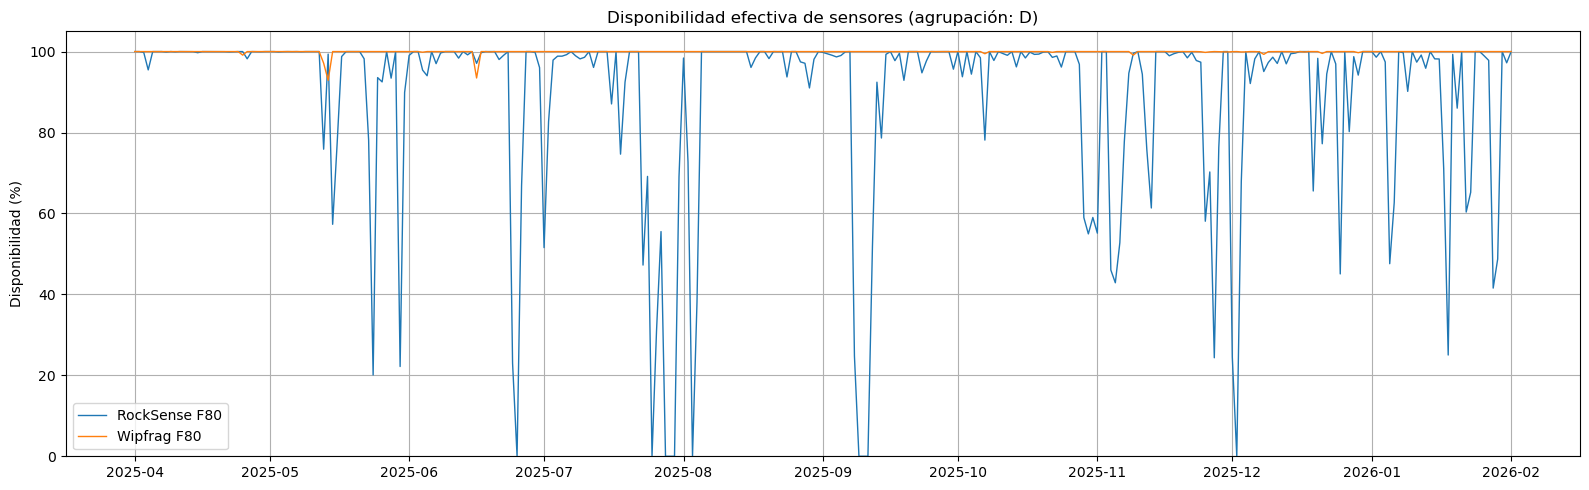

In [12]:
# Verificación de disponibilidad
resumen = calcular_disponibilidad_sensores(df_prepocesado, ['RockSense F80', 'Wipfrag F80'])
print(resumen)

# Tendencia diaria
disp_diaria = plot_disponibilidad_temporal(df_prepocesado, ['RockSense F80', 'Wipfrag F80'], freq='D')

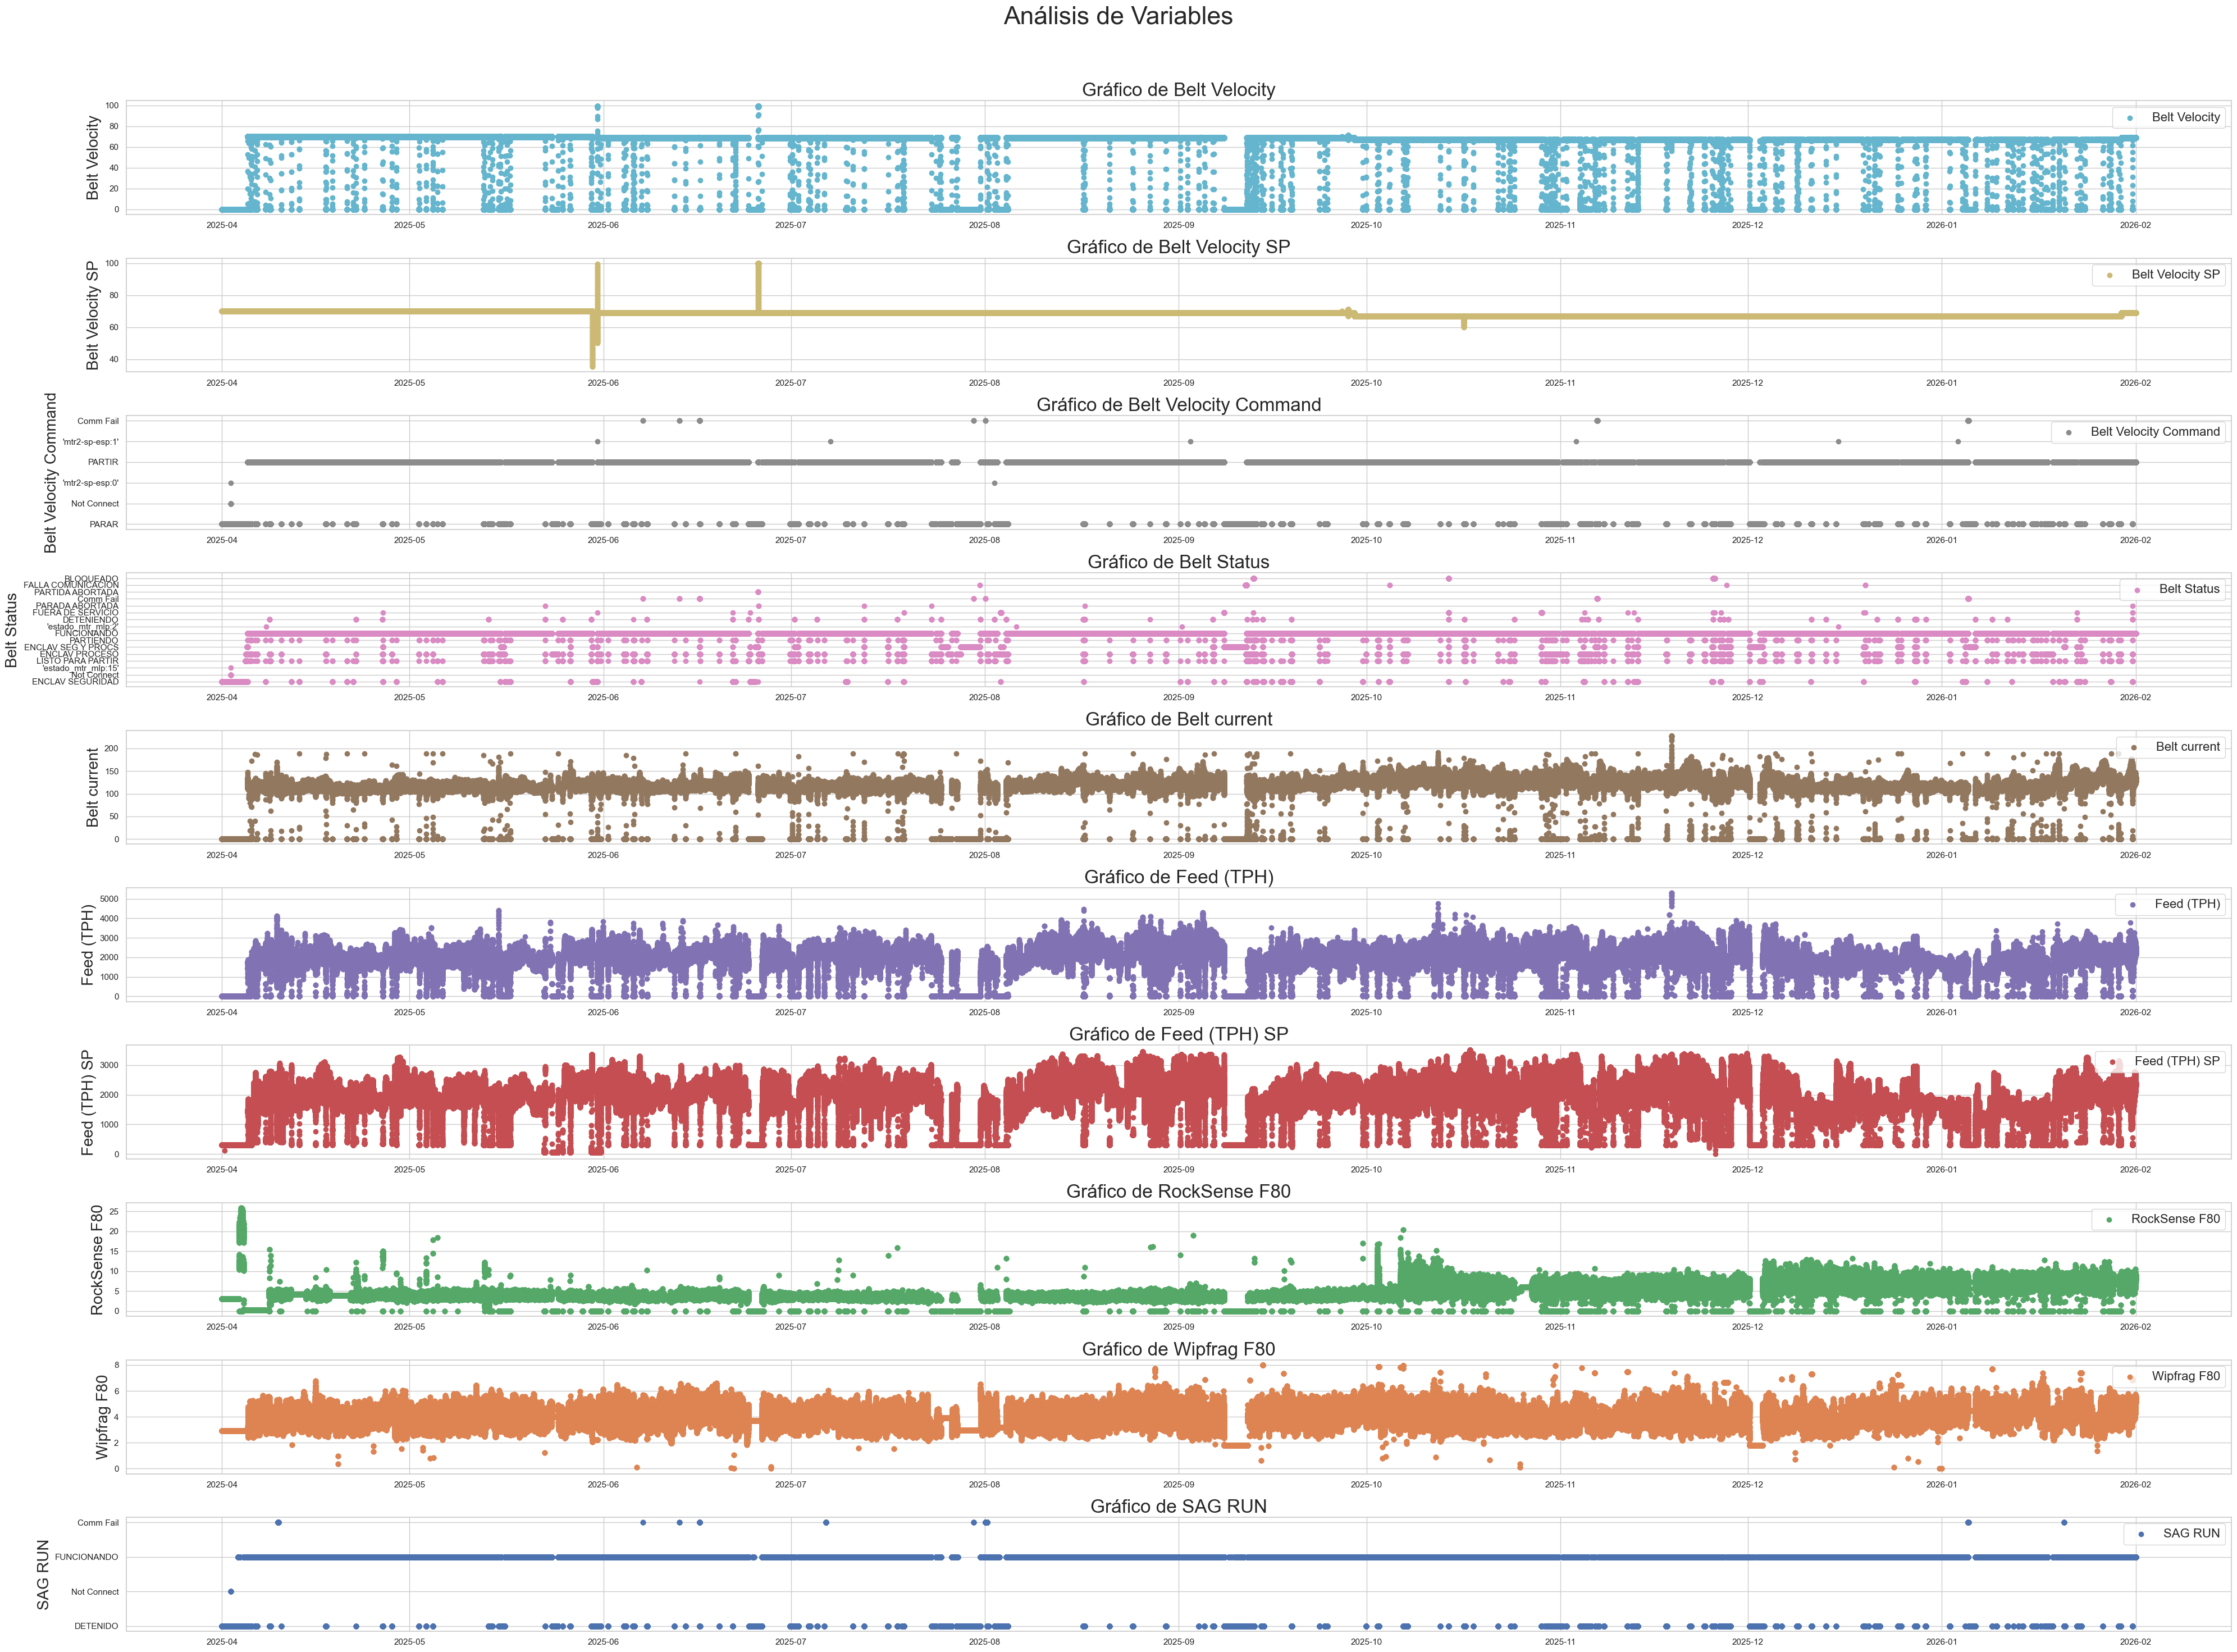

'Ploteo de variables exitoso'

In [13]:
columns_show = [column for column in df_prepocesado.columns if column != 'timestamp']

gbf.plot_variables(df_prepocesado, columns_show)

#### Debido al gráfico anterior, se decide hacer el análisis desde noviembre del 2025.

## Análisis local

In [14]:
df_prepocesado = df_prepocesado[df_prepocesado['Belt Status'] == 'FUNCIONANDO']
df_prepocesado = df_prepocesado[df_prepocesado.index > "2026-01-01"]
df_prepocesado['RockSense F80'] = df_prepocesado['RockSense F80'].fillna(value=df_prepocesado['RockSense F80'].mean())
df_prepocesado['Wipfrag F80'] = df_prepocesado['Wipfrag F80'].fillna(value=df_prepocesado['Wipfrag F80'].mean())

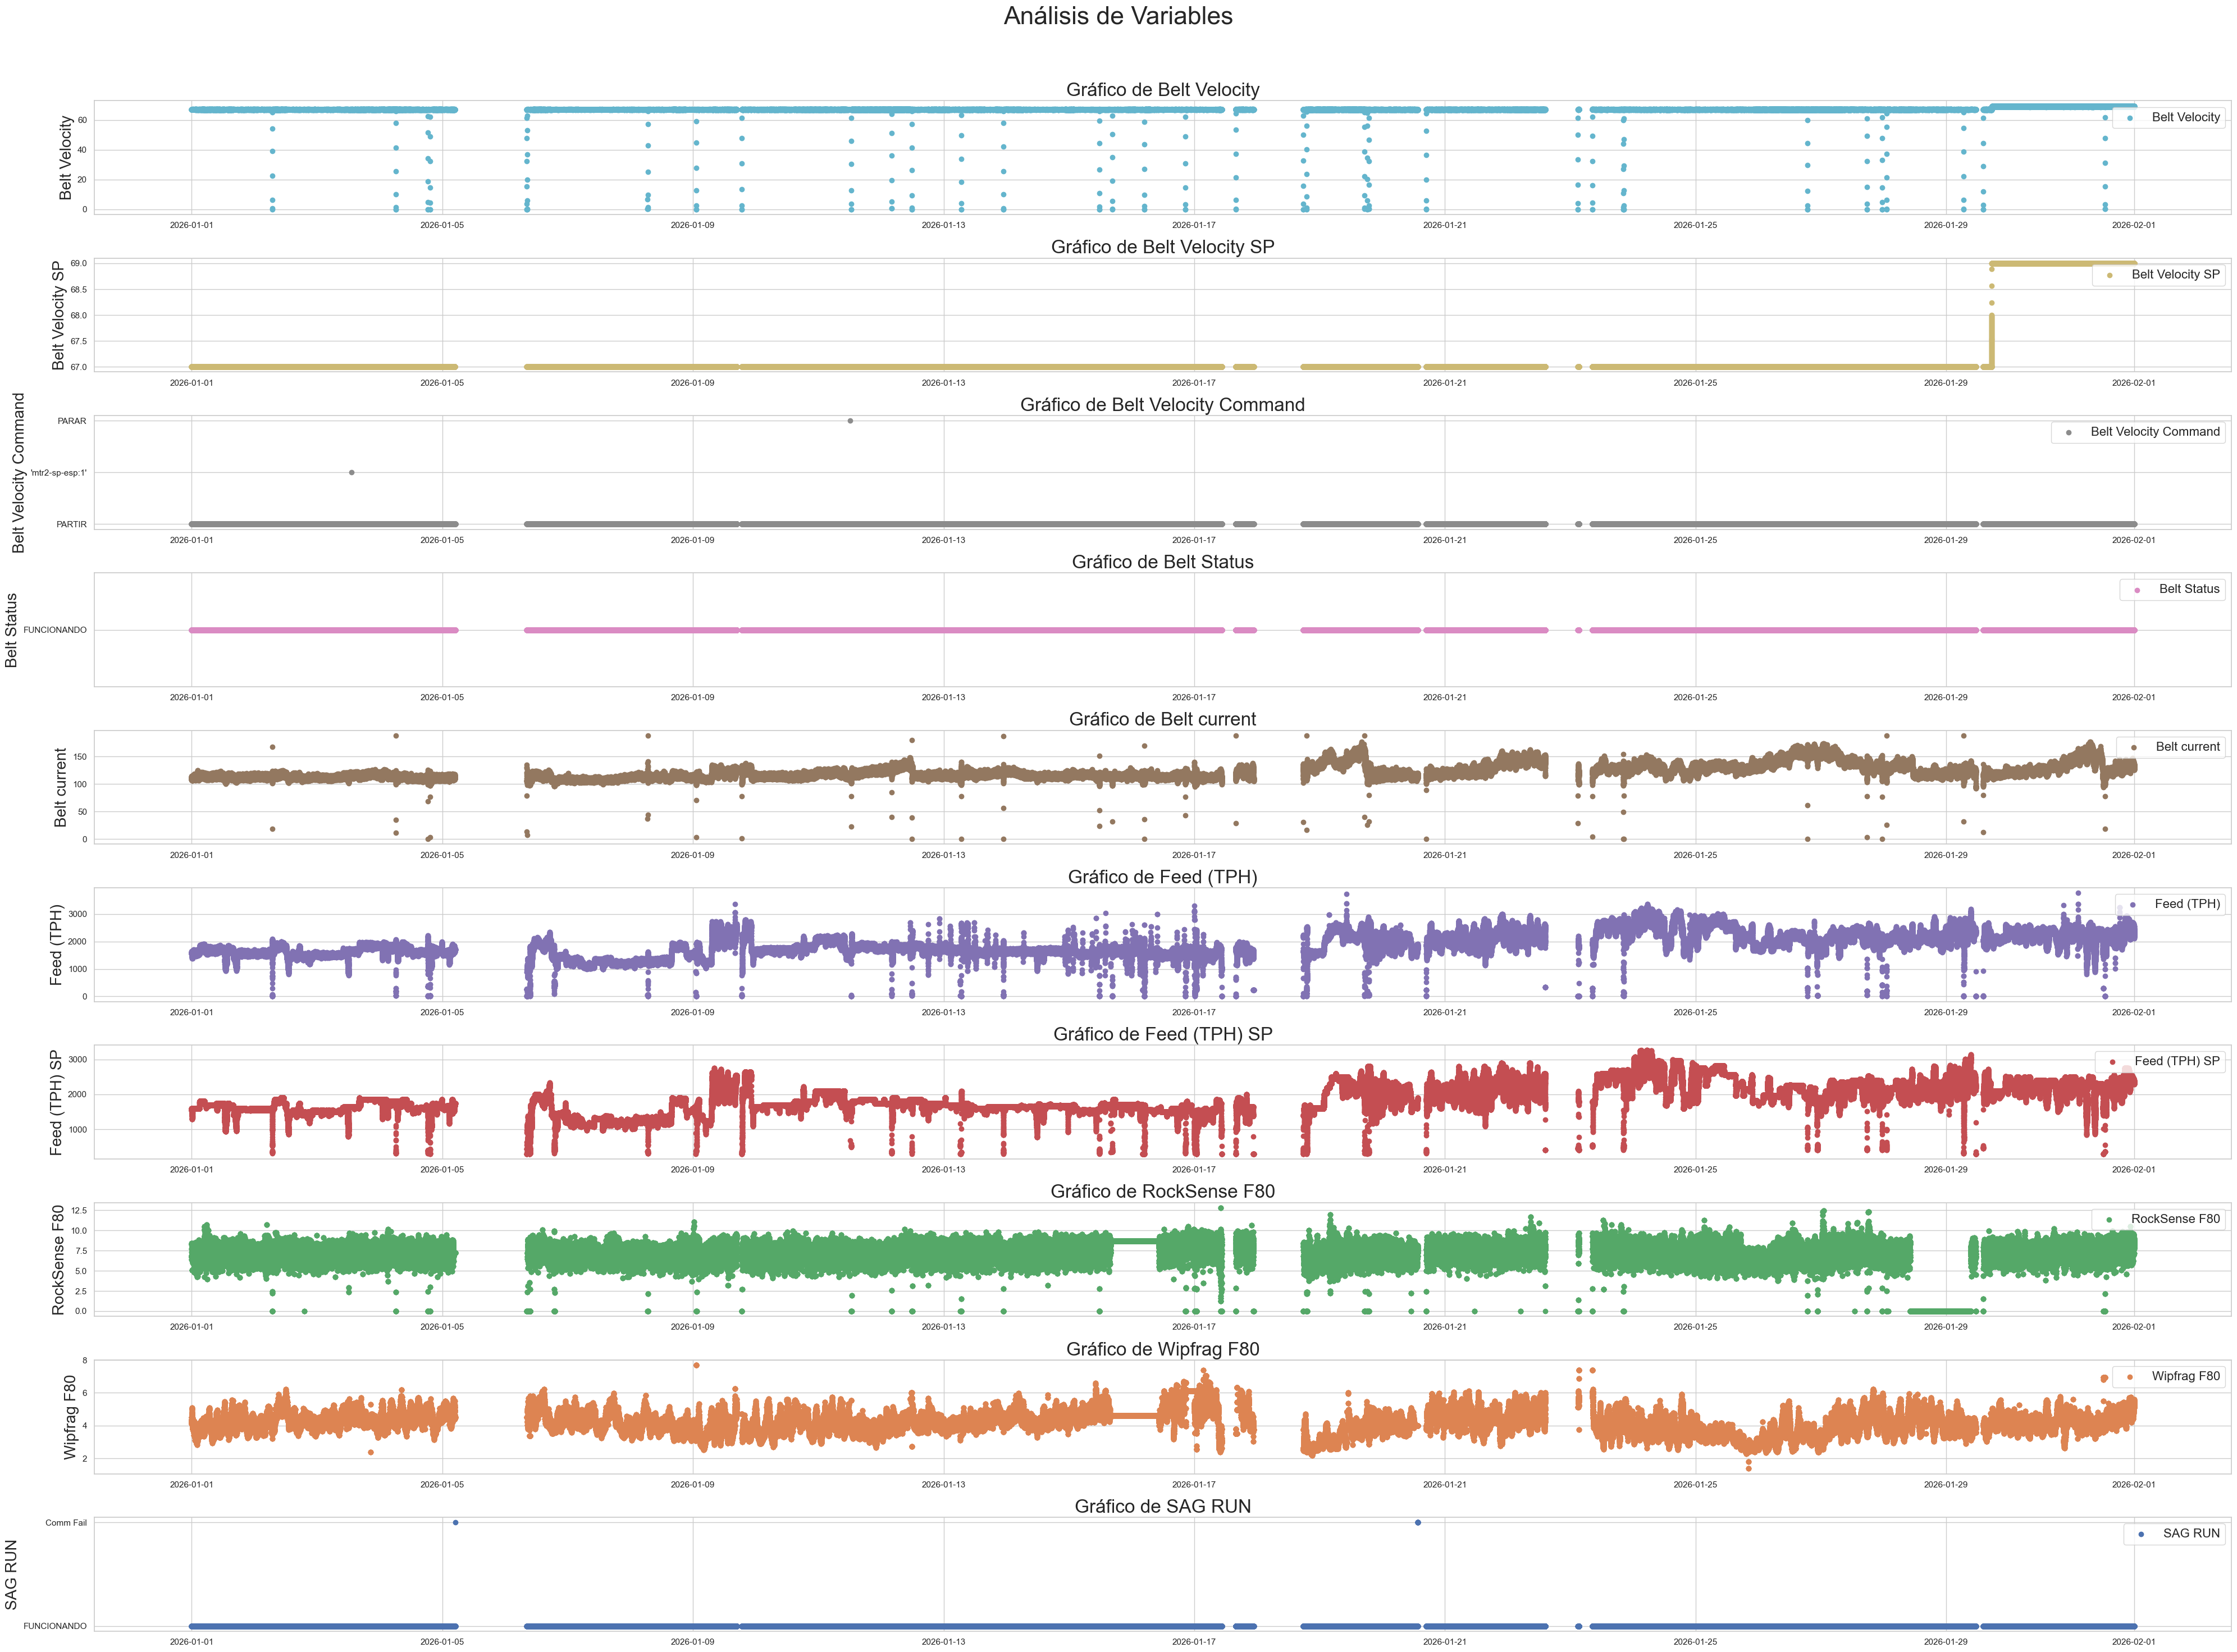

'Ploteo de variables exitoso'

In [15]:
gbf.plot_variables(df_prepocesado, columns_show)

In [17]:
df_cleaned = ad.remove_outliers(df_prepocesado, ['RockSense F80', 'Wipfrag F80'])

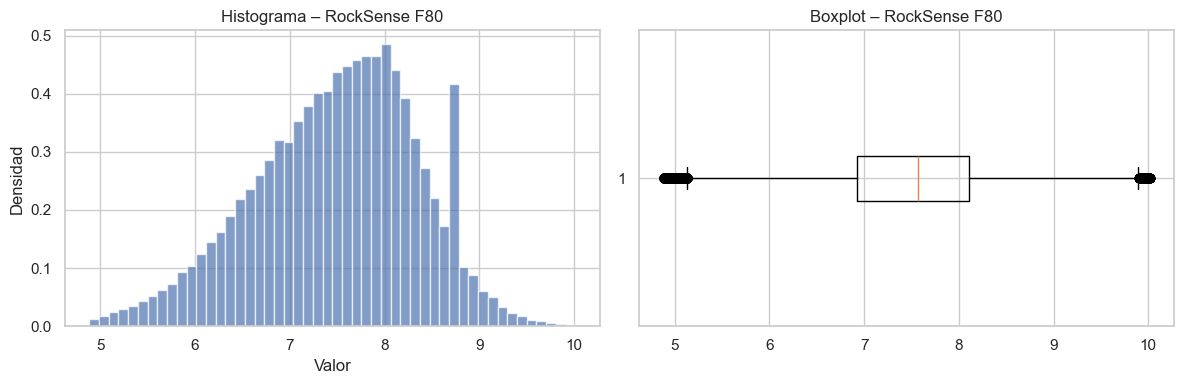

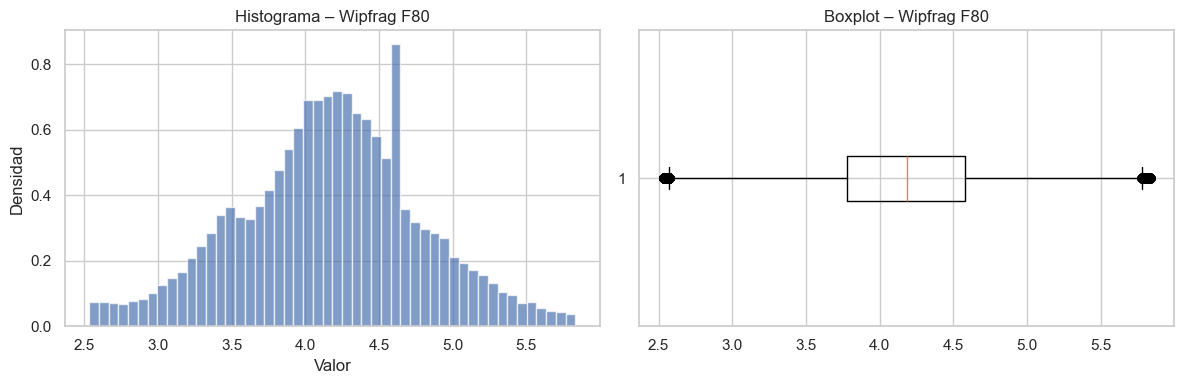

In [18]:
columns_show = ['RockSense F80', 'Wipfrag F80']
gbf.plot_individual_dist(df_cleaned, columns=columns_show)

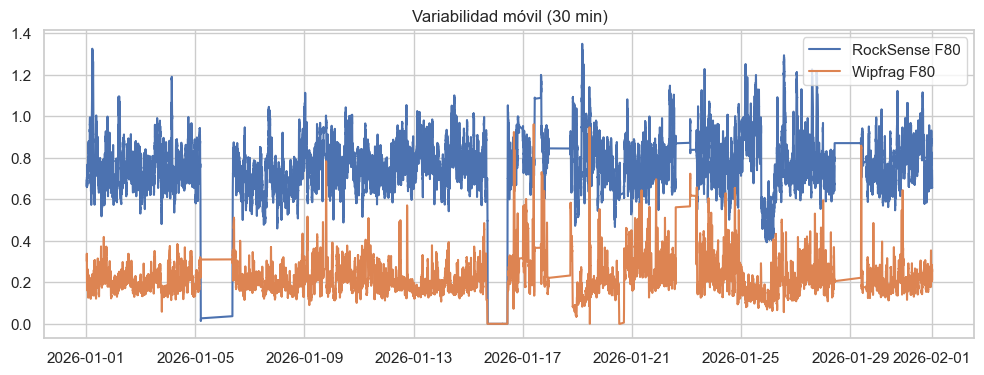

In [19]:
win = int(30 * 60 / 5)  # 30 minutos

sigma_movil_rck = df_cleaned['RockSense F80'].rolling(win).std()
sigma_movil_wp = df_cleaned['Wipfrag F80'].rolling(win).std()

plt.figure(figsize=(12,4))
plt.plot(sigma_movil_rck, label='RockSense F80')
plt.plot(sigma_movil_wp, label='Wipfrag F80')
plt.title('Variabilidad móvil (30 min)')
plt.grid(True)
plt.legend()
plt.show()

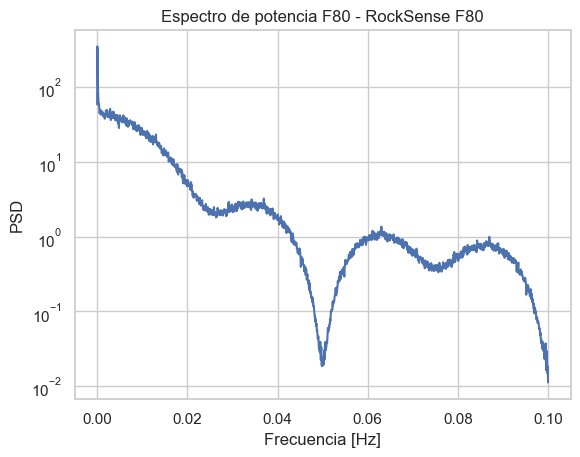

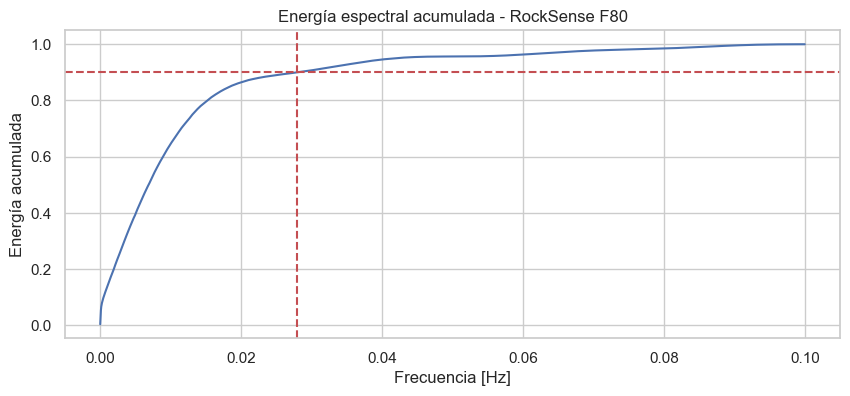

In [20]:
fc_rck, df_freq = freq_analyzer(df_cleaned, 'RockSense F80', fc_coef=0.1)

In [70]:
print(f"Frecuencia de corte para RockSense F80: {fc_rck:.4f} Hz")
print(1/(fc_rck))

Frecuencia de corte para RockSense F80: 0.0280 Hz
35.74171029668412


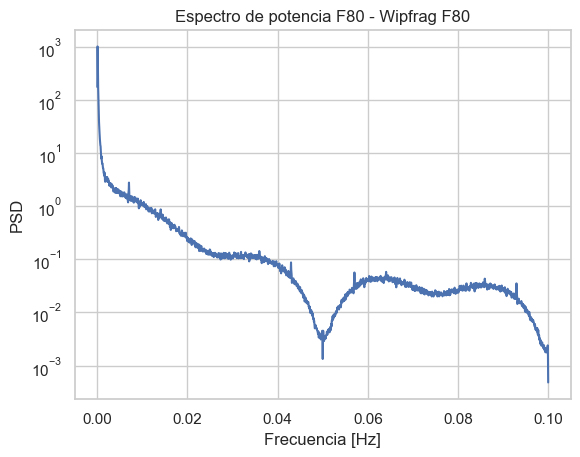

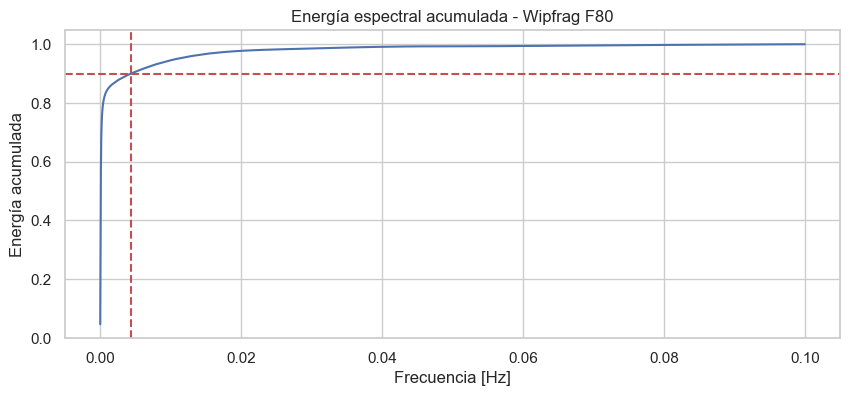

In [32]:
df_freq = freq_analyzer(df_freq, 'Wipfrag F80')

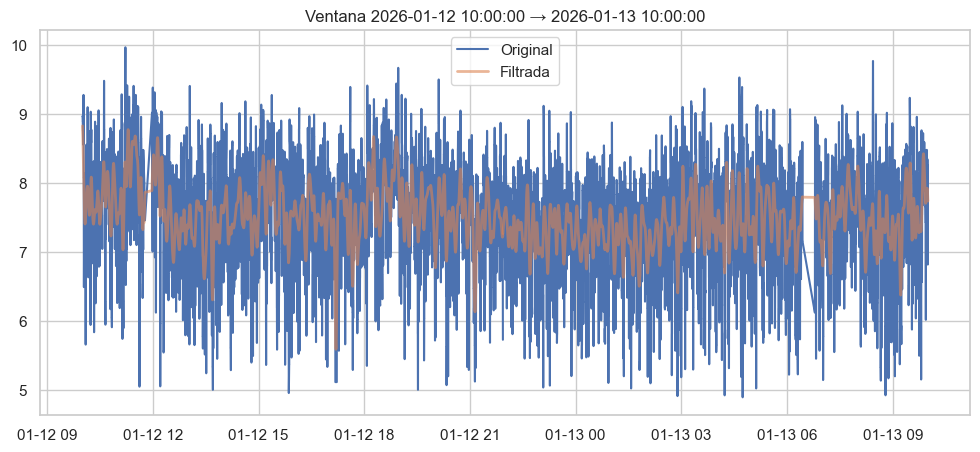

In [56]:
start = '2026-01-12 10:00:00'
end   = '2026-01-13 10:00:00'

df_slice = df_freq.loc[start:end]

plt.figure(figsize=(12,5))
plt.plot(df_slice['RockSense F80'], label='Original')
# plt.figure(figsize=(12,5))
plt.plot(df_slice['RockSense F80 filtered'], 
         alpha=0.6, linewidth=2, label='Filtrada')
plt.legend()
plt.title(f'Ventana {start} → {end}')
plt.grid(True)
plt.show()


In [57]:
x = df_freq['RockSense F80 filtered'].values.reshape(-1,1)
y = df_freq['Wipfrag F80'].values

mask = ~np.isnan(x[:,0]) & ~np.isnan(y)
x, y = x[mask], y[mask]

model = LinearRegression().fit(x, y)

a = model.coef_[0]
b = model.intercept_

print(f"y = {a:.3f} x + {b:.3f}")

y = 0.613 x + -0.428


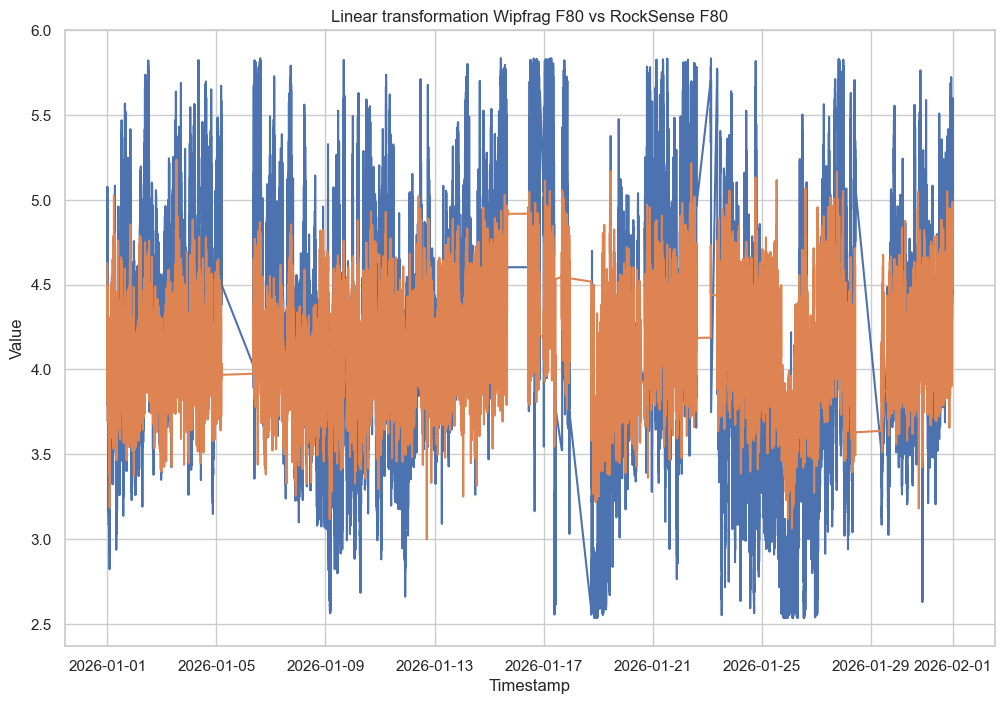

In [58]:
plt.figure(figsize=(12,8))
plt.plot(df_freq['Wipfrag F80']) 
plt.plot(a*df_freq['RockSense F80 filtered'] + b)
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.title('Linear transformation Wipfrag F80 vs RockSense F80')
plt.grid(True)
plt.show()


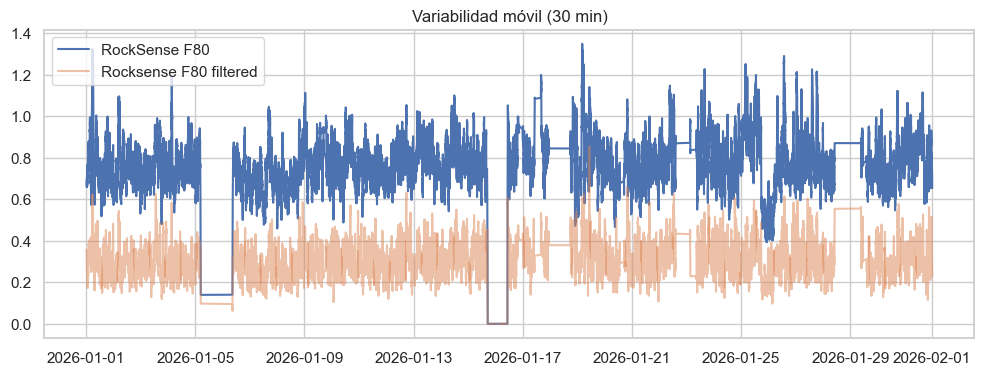

In [59]:
win = int(30 * 60 / 5)  # 30 minutos

sigma_movil_rck = df_freq['RockSense F80'].rolling(win).std()
sigma_movil_rck_filt = df_freq['RockSense F80 filtered'].rolling(win).std()

plt.figure(figsize=(12,4))
plt.plot(sigma_movil_rck, label='RockSense F80')
plt.plot(sigma_movil_rck_filt, label='Rocksense F80 filtered', alpha=0.5)
plt.title('Variabilidad móvil (30 min)')
plt.grid(True)
plt.legend()
plt.show()

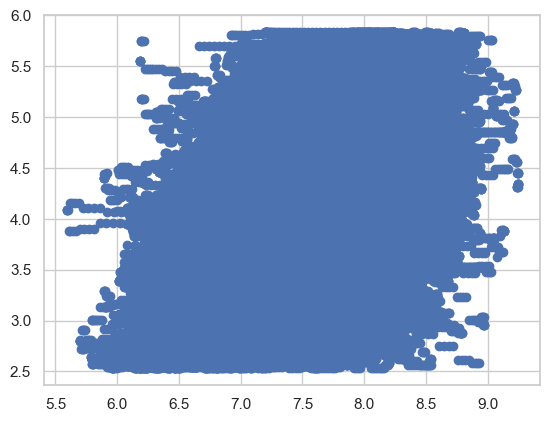

In [60]:
plt.scatter(df_freq['RockSense F80 filtered'], df_freq['Wipfrag F80'])

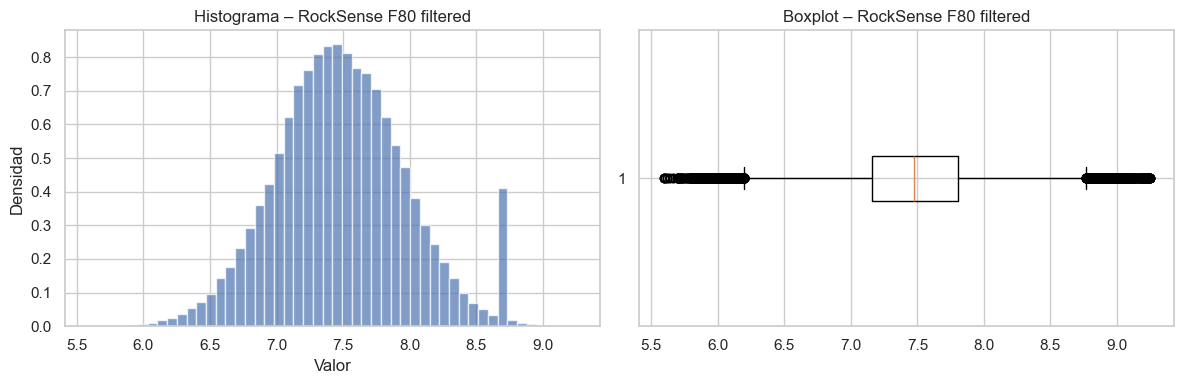

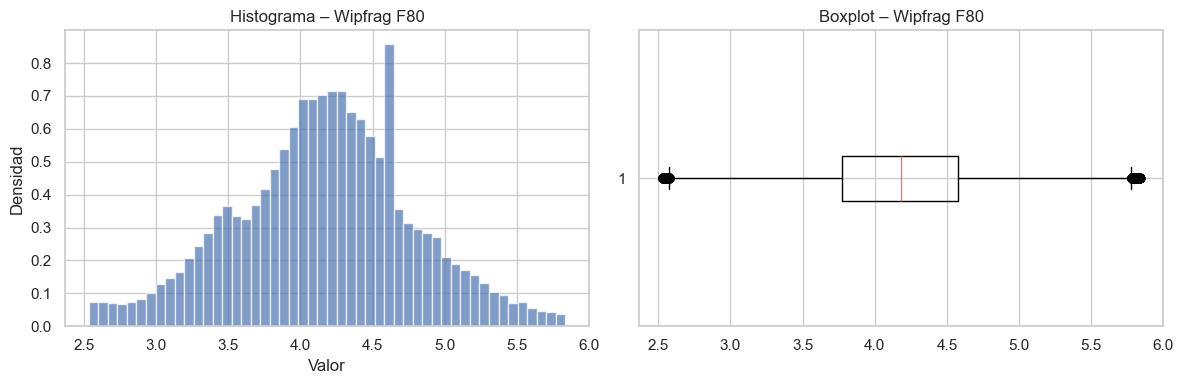

In [62]:
columns_show = ['RockSense F80 filtered', 'Wipfrag F80']
gbf.plot_individual_dist(df_freq, columns=columns_show)

## Correlación temporal

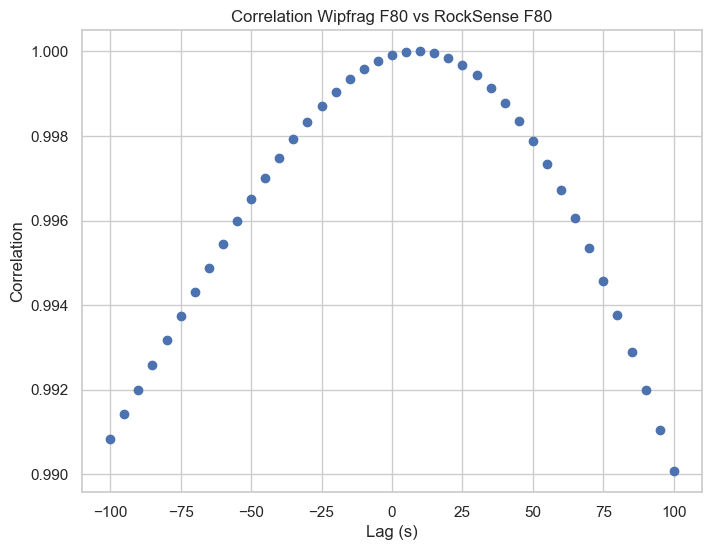

In [63]:
time_between_sample = 5
lags, corr = temporal_correlation(df_freq['Wipfrag F80'], df_freq['RockSense F80 filtered'], 1/time_between_sample)
mask = (lags >= -100) & (lags <= 100)
lags = lags[mask]
corr = corr[mask] 
plt.figure(figsize=(8,6))
plt.scatter(lags, corr)
plt.xlabel('Lag (s)')
plt.ylabel('Correlation')
plt.title('Correlation Wipfrag F80 vs RockSense F80')
plt.grid(True)
plt.show()

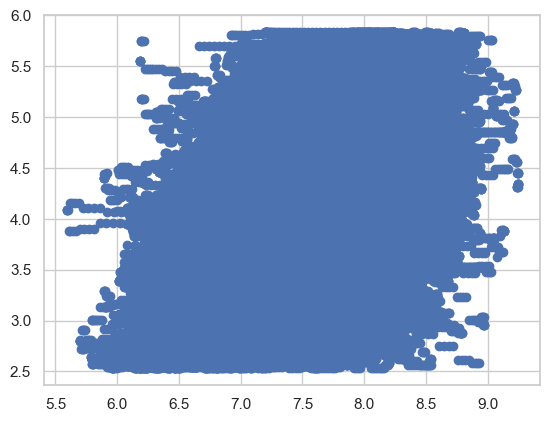

In [71]:
# Shift RockSense F80 by 40 seconds (8 samples)
df_freq['Wipfrag F80 shifted'] = df_freq['Wipfrag F80'].shift(2)
plt.scatter(df_freq['RockSense F80 filtered'], df_freq['Wipfrag F80'])

## Binning por Feed